Initializing Continuous Health Monitoring Inference Pipeline...
Preparing sequential tensors...
Loading pre-trained LSTM model...
Running inference on historical sequence data...
Writing clinical simulation feed to clinical_alert_log.txt...
Generating simulation dashboard graphs...
Graphs successfully saved to patient_simulation_dashboard.png
Pipeline execution complete.


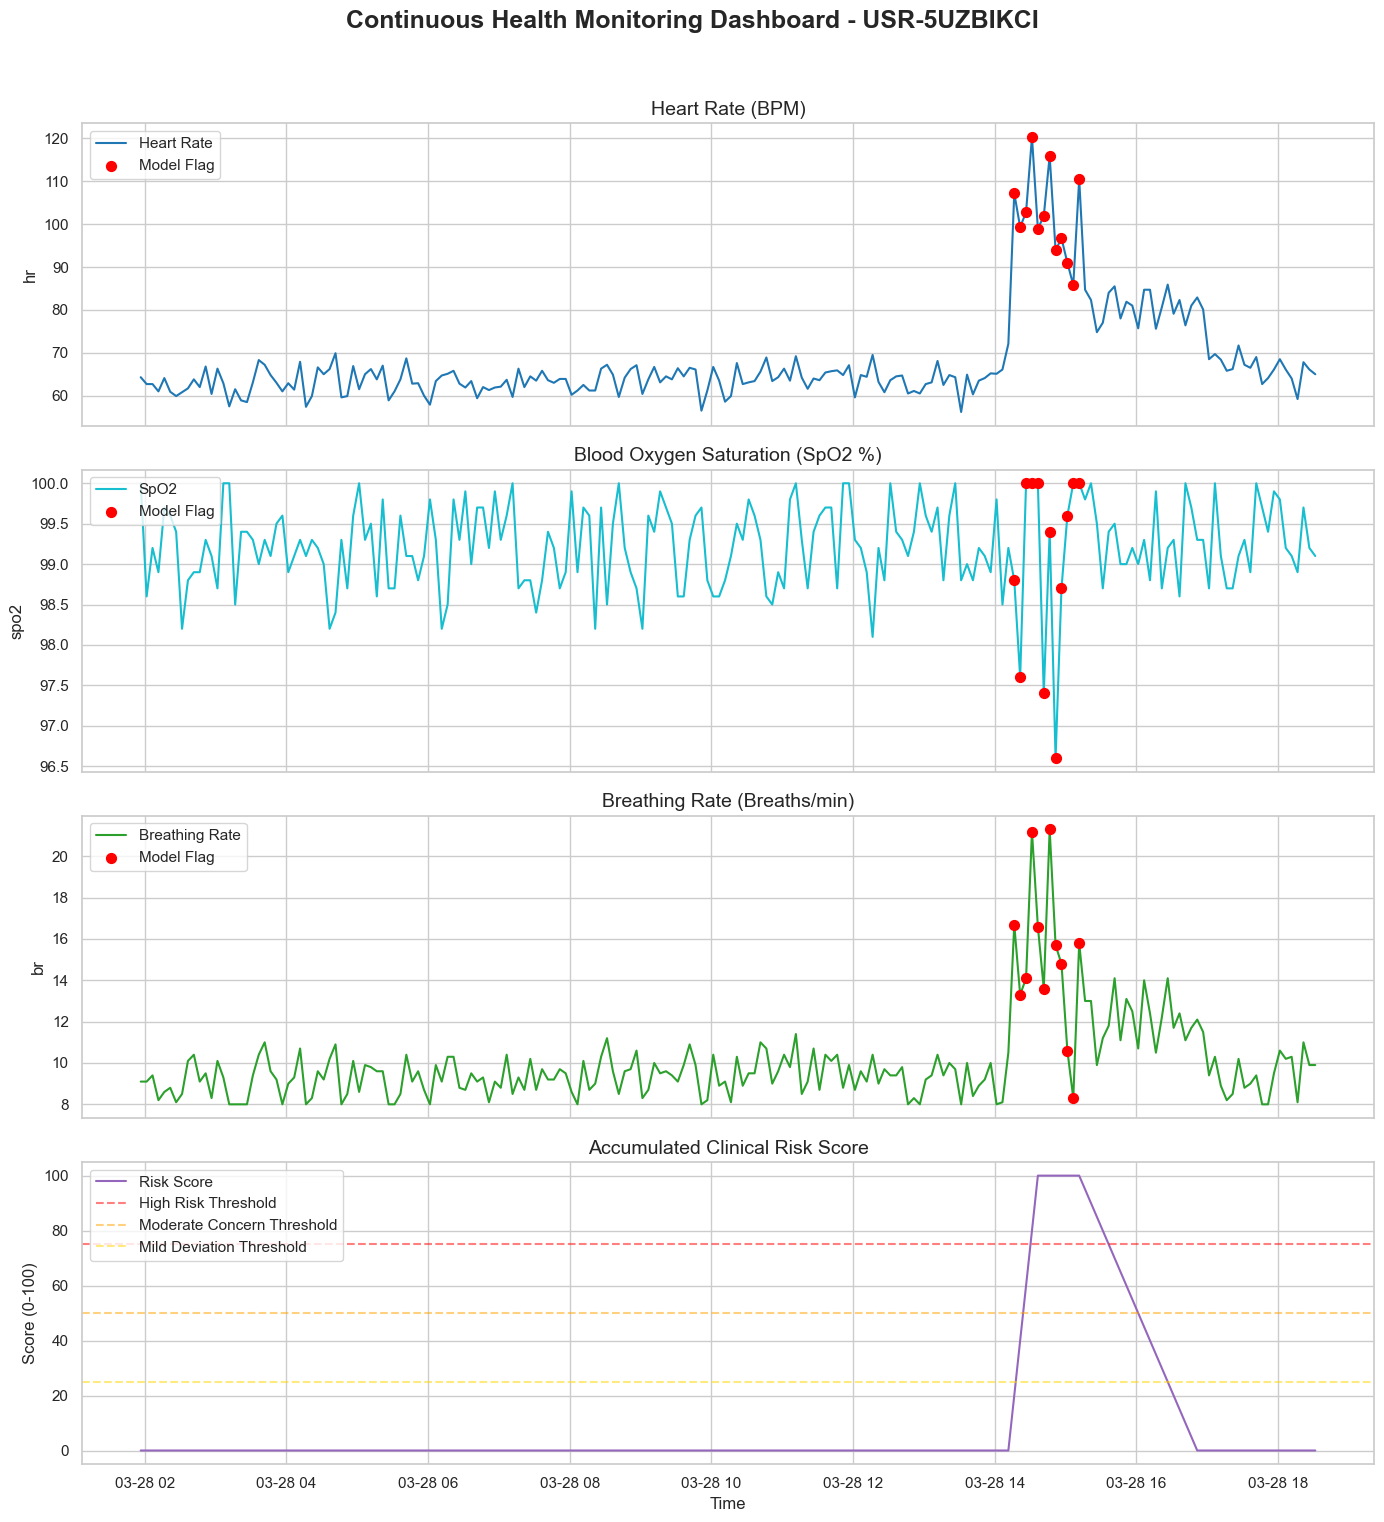

In [2]:
"""
Continuous Health Monitoring: Final Inference Pipeline
======================================================
This script integrates the entire workflow:
1. Data Ingestion & Preprocessing (Delta Calculations)
2. Sequence Generation for LSTM
3. Model Inference (Loading the pre-trained LSTM)
4. Alert Management (Risk accumulation and decay)
5. Clinical Reporting (Graphing and TXT logging)

Requires: pip install pandas numpy scikit-learn tensorflow matplotlib seaborn
"""

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration & Paths ---
EPOCHS_PATH = r"C:\Users\Akshat - Personal\Visual Studio Code\Sensera\sensera-poc\model_dev_v1\health_epochs.csv"
USERS_PATH = r"C:\Users\Akshat - Personal\Visual Studio Code\Sensera\sensera-poc\model_dev_v1\health_users.csv"
MODEL_PATH = r"C:\Users\Akshat - Personal\Visual Studio Code\Sensera\sensera-poc\model_dev_v1\lstm_anomaly_model.keras"

SEQUENCE_LENGTH = 12

class AlertManager:
    """
    Manages stateful risk scoring for users based on model predictions.
    Uses an accumulated risk bucket with normal decay to prevent alert fatigue.
    """
    def __init__(self, anomaly_penalty=15, normal_decay=5, max_score=100):
        self.anomaly_penalty = anomaly_penalty
        self.normal_decay = normal_decay
        self.max_score = max_score
        self.user_states = {}

    def get_alert_level(self, score):
        """Maps numerical risk score to clinical severity."""
        if score >= 75:
            return "HIGH RISK (Immediate Action Required)"
        elif score >= 50:
            return "MODERATE CONCERN (Monitor Closely)"
        elif score >= 25:
            return "MILD DEVIATION (Self-Check Suggested)"
        else:
            return "NORMAL"

    def process_epoch(self, user_id, timestamp, is_anomaly):
        """Processes a single prediction and updates the user's risk score."""
        if user_id not in self.user_states:
            self.user_states[user_id] = 0

        current_score = self.user_states[user_id]

        if is_anomaly:
            current_score += self.anomaly_penalty
        else:
            current_score -= self.normal_decay

        # Clamp score
        current_score = max(0, min(self.max_score, current_score))
        self.user_states[user_id] = current_score
        
        return {
            "timestamp": timestamp,
            "is_anomaly": is_anomaly,
            "risk_score": current_score,
            "alert_status": self.get_alert_level(current_score)
        }

def load_and_engineer_features(epochs_path, users_path):
    """Loads CSVs, merges baselines, and calculates physiological deltas."""
    epochs_df = pd.read_csv(epochs_path)
    users_df = pd.read_csv(users_path)
    
    df = epochs_df.merge(users_df, on="user_id", how="left")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(by=["user_id", "timestamp"]).reset_index(drop=True)

    df["delta_hr"] = df["mean_hr"] - df["baseline_hr"]
    df["delta_spo2"] = df["mean_spo2"] - df["baseline_spo2"]
    df["delta_br"] = df["mean_br"] - df["baseline_br"]
    
    return df

def prepare_simulation_data(df, feature_cols, sequence_length):
    """
    Transforms 2D data into 3D tensors and extracts metadata (timestamp/user)
    so we can map predictions back to specific moments in time.
    """
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])
    
    sequences, metadata = [], []
    
    for user_id, user_df in df_scaled.groupby("user_id"):
        features = user_df[feature_cols].values
        # Keep raw dataframe slice to extract actual timestamps
        raw_user_df = df[df["user_id"] == user_id].reset_index(drop=True)
        
        for i in range(len(features) - sequence_length):
            sequences.append(features[i : i + sequence_length])
            
            # The prediction applies to the END of the sequence window
            target_idx = i + sequence_length - 1
            metadata.append({
                "user_id": user_id,
                "timestamp": raw_user_df.loc[target_idx, "timestamp"],
                "raw_hr": raw_user_df.loc[target_idx, "mean_hr"],
                "raw_spo2": raw_user_df.loc[target_idx, "mean_spo2"],
                "raw_br": raw_user_df.loc[target_idx, "mean_br"],
                "true_state": raw_user_df.loc[target_idx, "true_latent_state"]
            })
            
    return np.array(sequences), metadata

def main():
    print("Initializing Continuous Health Monitoring Inference Pipeline...")
    
    # 1. Load Data
    try:
        df = load_and_engineer_features(EPOCHS_PATH, USERS_PATH)
    except FileNotFoundError:
        print("Error: Could not find data files.")
        return

    feature_cols = [
        "mean_hr", "delta_hr", "max_hr",
        "mean_spo2", "delta_spo2", "min_spo2",
        "mean_br", "delta_br", "hr_br_ratio"
    ]

    # 2. Prepare Sequences and Metadata
    print("Preparing sequential tensors...")
    X, meta = prepare_simulation_data(df, feature_cols, SEQUENCE_LENGTH)

    # 3. Load Model
    if not os.path.exists(MODEL_PATH):
        print(f"Error: Could not find model at {MODEL_PATH}")
        return
        
    print("Loading pre-trained LSTM model...")
    model = tf.keras.models.load_model(MODEL_PATH)

    # 4. Run Inference (Batch prediction for speed)
    print("Running inference on historical sequence data...")
    predictions = model.predict(X, verbose=0)
    is_anomaly_pred = (predictions > 0.5).astype(bool).flatten()

    # 5. Simulate Real-Time Alerting & Collect Data for Graphing
    alert_engine = AlertManager(anomaly_penalty=20, normal_decay=5)
    
    target_user = meta[0]["user_id"]
    user_indices = [i for i, m in enumerate(meta) if m["user_id"] == target_user]
    
    simulation_records = []
    log_file_path = "clinical_alert_log.txt"
    
    print(f"Writing clinical simulation feed to {log_file_path}...")
    
    with open(log_file_path, "w") as log_file:
        log_file.write("================================================================================\n")
        log_file.write(f"CLINICAL RISK SIMULATION LOG (Patient: {target_user})\n")
        log_file.write("================================================================================\n")
        
        # Iterate through the user's timeline (taking first 200 epochs to show a good graph)
        for idx in user_indices[:200]: 
            m = meta[idx]
            anomaly_flag = is_anomaly_pred[idx]
            
            result = alert_engine.process_epoch(
                user_id=m["user_id"], 
                timestamp=m["timestamp"], 
                is_anomaly=anomaly_flag
            )
            
            # Formatting the output report
            ts_str = result["timestamp"].strftime("%Y-%m-%d %H:%M")
            hr_str = f"HR:{m['raw_hr']:>5.1f}"
            spo2_str = f"SpO2:{m['raw_spo2']:>5.1f}"
            br_str = f"BR:{m['raw_br']:>5.1f}"
            anom_marker = "[!]" if anomaly_flag else "[ ]"
            
            # Write to text file
            log_line = f"{ts_str} | {hr_str} | {spo2_str} | {br_str} | Model Flag: {anom_marker} | Score: {result['risk_score']:>3} | Alert: {result['alert_status']}\n"
            log_file.write(log_line)
            
            # Collect data for plotting
            simulation_records.append({
                "timestamp": result["timestamp"],
                "hr": m["raw_hr"],
                "spo2": m["raw_spo2"],
                "br": m["raw_br"],
                "is_anomaly": anomaly_flag,
                "risk_score": result["risk_score"]
            })

    # 6. Generate and Save Visualizations
    print("Generating simulation dashboard graphs...")
    sim_df = pd.DataFrame(simulation_records)
    anomalies = sim_df[sim_df["is_anomaly"] == True]

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
    fig.suptitle(f"Continuous Health Monitoring Dashboard - {target_user}", fontsize=18, fontweight='bold')

    # HR Plot
    sns.lineplot(data=sim_df, x="timestamp", y="hr", ax=axes[0], color="tab:blue", label="Heart Rate")
    if not anomalies.empty:
        axes[0].scatter(anomalies["timestamp"], anomalies["hr"], color="red", s=50, zorder=5, label="Model Flag")
    axes[0].set_title("Heart Rate (BPM)", fontsize=14)
    axes[0].legend(loc="upper left")

    # SpO2 Plot
    sns.lineplot(data=sim_df, x="timestamp", y="spo2", ax=axes[1], color="tab:cyan", label="SpO2")
    if not anomalies.empty:
        axes[1].scatter(anomalies["timestamp"], anomalies["spo2"], color="red", s=50, zorder=5, label="Model Flag")
    axes[1].set_title("Blood Oxygen Saturation (SpO2 %)", fontsize=14)
    axes[1].legend(loc="upper left")

    # BR Plot
    sns.lineplot(data=sim_df, x="timestamp", y="br", ax=axes[2], color="tab:green", label="Breathing Rate")
    if not anomalies.empty:
        axes[2].scatter(anomalies["timestamp"], anomalies["br"], color="red", s=50, zorder=5, label="Model Flag")
    axes[2].set_title("Breathing Rate (Breaths/min)", fontsize=14)
    axes[2].legend(loc="upper left")

    # Risk Score Plot
    sns.lineplot(data=sim_df, x="timestamp", y="risk_score", ax=axes[3], color="tab:purple", label="Risk Score")
    axes[3].axhline(75, color='red', linestyle='--', alpha=0.5, label='High Risk Threshold')
    axes[3].axhline(50, color='orange', linestyle='--', alpha=0.5, label='Moderate Concern Threshold')
    axes[3].axhline(25, color='gold', linestyle='--', alpha=0.5, label='Mild Deviation Threshold')
    
    axes[3].set_title("Accumulated Clinical Risk Score", fontsize=14)
    axes[3].set_xlabel("Time", fontsize=12)
    axes[3].set_ylabel("Score (0-100)", fontsize=12)
    axes[3].legend(loc="upper left")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    
    chart_path = "patient_simulation_dashboard.png"
    plt.savefig(chart_path, dpi=300)
    print(f"Graphs successfully saved to {chart_path}")
    print("Pipeline execution complete.")

if __name__ == "__main__":
    main()